In [39]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
import requests

In [40]:
from langchain_core.tools import InjectedToolArg
from typing import Annotated

import json

#### 2 tool create : 
1. conversion factor
2. multiplication

In [41]:
# tool create

@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
    """
    This function fetches the currency conversion factor between a given base currency and a target currency
    """
    
    url = f'https://v6.exchangerate-api.com/v6/7e7b23915418523426764300/pair/{base_currency}/{target_currency}'
    
    response = requests.get(url)
    
    return response.json()

In [42]:
get_conversion_factor.invoke({'base_currency':'USD', 'target_currency':'INR'})

{'result': 'success',
 'documentation': 'https://www.exchangerate-api.com/docs',
 'terms_of_use': 'https://www.exchangerate-api.com/terms',
 'time_last_update_unix': 1756252801,
 'time_last_update_utc': 'Wed, 27 Aug 2025 00:00:01 +0000',
 'time_next_update_unix': 1756339201,
 'time_next_update_utc': 'Thu, 28 Aug 2025 00:00:01 +0000',
 'base_code': 'USD',
 'target_code': 'INR',
 'conversion_rate': 87.6692}

In [43]:
# multiplcation tool
@tool
def convert(base_currency_value : int, conversion_rate : float) -> float:
    """
    given a currency conversion rate this function calculates the target currency value from a given base currency value 
    """
    
    return base_currency_value * conversion_rate

In [44]:
convert.invoke({'base_currency_value':10, 'conversion_rate':85.16})

851.5999999999999

Both the tools created

### Now bind both the tools : 

In [45]:
# tool binding

llm = ChatOpenAI()

In [46]:
llm_with_tools = llm.bind_tools([get_conversion_factor, convert])

### tool calling

In [47]:
messages = [HumanMessage('What is the conversion factor between USD and INR, and based on that can you convert 10 USD to INR')]

In [48]:
messages

[HumanMessage(content='What is the conversion factor between USD and INR, and based on that can you convert 10 USD to INR', additional_kwargs={}, response_metadata={})]

In [49]:
ai_message = llm_with_tools.invoke(messages)
ai_message

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_yAt4FW3vDMNKSEgXFdot5U9S', 'function': {'arguments': '{"base_currency": "USD", "target_currency": "INR"}', 'name': 'get_conversion_factor'}, 'type': 'function'}, {'id': 'call_w2giQPS49cnC3MliEXiU55SH', 'function': {'arguments': '{"base_currency_value": 10, "conversion_rate": 74.5}', 'name': 'convert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 127, 'total_tokens': 186, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-C9GvnBqTvYRbQVIPQNJMNYE04E67E', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--e9fe1a1f-2e56-43d7-8ea4-a9e4a14474c2-0', tool_calls=[{'name': 'get_conversion_fa

In [50]:

messages.append(ai_message)


In [51]:
ai_message.tool_calls # we can see 2 tool calls here

[{'name': 'get_conversion_factor',
  'args': {'base_currency': 'USD', 'target_currency': 'INR'},
  'id': 'call_yAt4FW3vDMNKSEgXFdot5U9S',
  'type': 'tool_call'},
 {'name': 'convert',
  'args': {'base_currency_value': 10, 'conversion_rate': 74.5},
  'id': 'call_w2giQPS49cnC3MliEXiU55SH',
  'type': 'tool_call'}]

**Here the issue is that the LLM is not taking the value of conversion provided by the tool earlier but from its history/knowlege taking the value of conversion which is 74.23. We need to inject the current value of conversion here using `InjectedToolArg`**

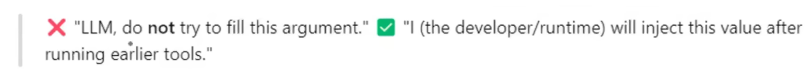

In [52]:
# recreating the multiplication tool

# multiplcation tool
@tool
def convert(base_currency_value : int, conversion_rate : Annotated[float, InjectedToolArg]) -> float:
    """
    given a currency conversion rate this function calculates the target currency value from a given base currency value 
    """
    
    return base_currency_value * conversion_rate

In [53]:
llm_with_tools = llm.bind_tools([get_conversion_factor, convert])

messages = [HumanMessage('What is the conversion factor between USD and INR, and based on that can you convert 10 USD to INR')]

ai_message = llm_with_tools.invoke(messages)

messages.append(ai_message)

ai_message.tool_calls # now we can see in the convert tool the LLM is not taking the conversion rate

[{'name': 'get_conversion_factor',
  'args': {'base_currency': 'USD', 'target_currency': 'INR'},
  'id': 'call_aVt5ujFRErIAu6naqdkKLhje',
  'type': 'tool_call'},
 {'name': 'convert',
  'args': {'base_currency_value': 10},
  'id': 'call_lgW2o8pecZSqOoPFV5PKXvxc',
  'type': 'tool_call'}]

In [54]:
for tool_call in ai_message.tool_calls:
    print(tool_call)

{'name': 'get_conversion_factor', 'args': {'base_currency': 'USD', 'target_currency': 'INR'}, 'id': 'call_aVt5ujFRErIAu6naqdkKLhje', 'type': 'tool_call'}
{'name': 'convert', 'args': {'base_currency_value': 10}, 'id': 'call_lgW2o8pecZSqOoPFV5PKXvxc', 'type': 'tool_call'}


In [55]:
for tool_call in ai_message.tool_calls:
    # execute the 1st tool and get the value of conversion rate
    if tool_call['name'] == 'get_conversion_factor':
        tool_message1 = get_conversion_factor.invoke(tool_call)
        # fetch this conversion rate
        conversion_rate = json.loads(tool_message1.content)['conversion_rate'] # extract conversion rate from the tool call1
        # append this tool message to message list
        messages.append(tool_message1)
        
        
    # execute the 2nd tool using the conversion rate from tool 1
    if tool_call['name'] == 'convert':
        # fetch the current arg and add 1 more argument conversion rate (arg_inject)
        tool_call['args']['conversion_rate'] = conversion_rate # adding the new conversion rate into the dictionary
        tool_message2 = convert.invoke(tool_call)
        messages.append(tool_message2)
    
    

In [56]:
messages

[HumanMessage(content='What is the conversion factor between USD and INR, and based on that can you convert 10 USD to INR', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_aVt5ujFRErIAu6naqdkKLhje', 'function': {'arguments': '{"base_currency": "USD", "target_currency": "INR"}', 'name': 'get_conversion_factor'}, 'type': 'function'}, {'id': 'call_lgW2o8pecZSqOoPFV5PKXvxc', 'function': {'arguments': '{"base_currency_value": 10}', 'name': 'convert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 122, 'total_tokens': 174, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-C9GvpTHTxUhd1dcAfmSHtu3657wAJ', 'service_tier': 'defa

In [ ]:
# passing entire message to LLM

final_result = llm_with_tools.invoke(messages)
final_result

AIMessage(content='The conversion factor between USD and INR is 87.6692. \n\nBased on this conversion factor, 10 USD is equivalent to 876.692 INR.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 333, 'total_tokens': 369, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-C9Gx23KAqK9ta6Z5jfgEq7ay85xFg', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--b2bada71-d9c1-46e5-b55e-236bb3b324d4-0', usage_metadata={'input_tokens': 333, 'output_tokens': 36, 'total_tokens': 369, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
final_result.content

'The conversion factor between USD and INR is 87.6692.\n\nBased on this conversion factor, 10 USD is equivalent to 876.692 INR.'

## How AI Agent will run this code as it doesnot need any human interference:

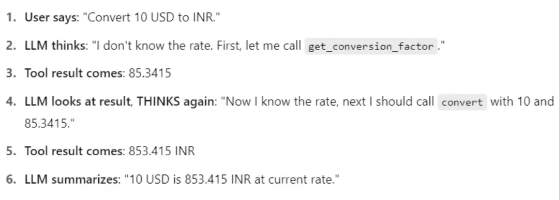

In [ ]:
# from langchain.agents import initialize_agent, AgentType

# # Step 5: Initialize the Agent ---
# agent_executor = initialize_agent(
#     tools=[get_conversion_factor, convert],
#     llm=llm,
#     agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,  # using ReAct pattern
#     verbose=True  # shows internal thinking
# )

In [ ]:
# # --- Step 6: Run the Agent ---
# user_query = "Hi how are you?"

# response = agent_executor.invoke({"input": user_query})